# 05 - Airport Supply Analysis

This notebook evaluates two questions from the airport analysis:

1. **When and how severe is the airport demand–supply mismatch?**
2. **What happens to captains after an airport-origin trip?**

The goal is to determine whether the strongest intervention is broad airport-catchment acquisition or a more targeted supply/economics intervention.

> **Scope:** `airport_hourly.csv` covers hourly demand and supply by zone. `airport_trips.csv` contains airport-origin trips only, so post-trip behavior is analyzed by **drop-zone type**, not against a non-airport control group.

## 0. Load the airport datasets

Keep this notebook focused on the two airport-specific datasets used for B1 and B2.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
airport_hourly = pd.read_csv(
    "../data/airport_hourly.csv",
    parse_dates=["hour_ts"]
)

In [3]:
airport_trips = pd.read_csv("../data/airport_trips.csv")

In [4]:
print("airport_hourly:", airport_hourly.shape)
print("airport_trips:", airport_trips.shape)

airport_hourly: (10248, 9)
airport_trips: (60000, 9)


In [5]:
print("airport_hourly columns:")
print(airport_hourly.columns.tolist())

airport_hourly columns:
['zone_id', 'zone_type', 'hour_ts', 'requests', 'fulfilled_requests', 'unfulfilled_requests', 'online_captains', 'avg_eta_min', 'avg_surge_multiplier']


In [6]:
print("airport_trips columns:")
print(airport_trips.columns.tolist())

airport_trips columns:
['trip_id', 'pickup_zone_id', 'drop_zone_id', 'drop_zone_type', 'request_ts', 'trip_distance_km', 'captain_cancelled', 'got_return_fare_within_20min', 'fare_inr']


## 1. B1 - Airport demand–supply mismatch

I first isolate `airport_terminal` rows because these represent the airport supply problem directly.

For the overall rate, the denominator is **all terminal requests**:

`unfulfilled rate = total unfulfilled requests / total requests`

For hourly patterns, requests and unfulfilled requests are summed across terminal zones and dates for each clock hour. Supply, ETA, and surge are reported as averages across the corresponding hourly observations.

In [7]:
airport_hourly["unfulfilled_rate"] = (
    airport_hourly["unfulfilled_requests"]
    / airport_hourly["requests"]
)

In [8]:
terminal_hourly = airport_hourly[
    airport_hourly["zone_type"].eq("airport_terminal")
].copy()

In [9]:
terminal_metrics = pd.Series({
    "terminal_rows": len(terminal_hourly),
    "requests": terminal_hourly["requests"].sum(),
    "fulfilled_requests": terminal_hourly["fulfilled_requests"].sum(),
    "unfulfilled_requests": terminal_hourly["unfulfilled_requests"].sum(),
    "unfulfilled_rate_pct": (
        terminal_hourly["unfulfilled_requests"].sum()
        / terminal_hourly["requests"].sum()
        * 100
    ),
    "avg_online_captains": terminal_hourly["online_captains"].mean(),
    "avg_eta_min": terminal_hourly["avg_eta_min"].mean(),
    "avg_surge_multiplier": terminal_hourly["avg_surge_multiplier"].mean()
})

In [10]:
display(terminal_metrics.to_frame("value").round(2))

,value
terminal_rows,2928.00
requests,136814.00
fulfilled_requests,81756.00
unfulfilled_requests,55058.00
unfulfilled_rate_pct,40.24
avg_online_captains,29.79
avg_eta_min,5.75
avg_surge_multiplier,1.41


In [11]:
# How much of the total airport_hourly unfulfilled demand occurs at terminals?

all_zone_unfulfilled = airport_hourly["unfulfilled_requests"].sum()
terminal_unfulfilled = terminal_hourly["unfulfilled_requests"].sum()

In [12]:
terminal_share_of_unfulfilled = (
    terminal_unfulfilled / all_zone_unfulfilled * 100
)

In [13]:
print(
    f"Terminal share of all unfulfilled requests: "
    f"{terminal_share_of_unfulfilled:.2f}%"
)

Terminal share of all unfulfilled requests: 85.57%


### Hour-of-day concentration

The next table ranks clock hours by terminal unfulfilled rate. This helps distinguish a broad airport problem from a problem concentrated in particular operating windows.

In [14]:
hourly_pressure = (
    terminal_hourly
    .assign(hour=terminal_hourly["hour_ts"].dt.hour)
    .groupby("hour")
    .agg(
        requests=("requests", "sum"),
        unfulfilled=("unfulfilled_requests", "sum"),
        avg_online_captains=("online_captains", "mean"),
        avg_eta_min=("avg_eta_min", "mean"),
        avg_surge_multiplier=("avg_surge_multiplier", "mean")
    )
)

In [15]:
hourly_pressure["unfulfilled_rate_pct"] = (
    hourly_pressure["unfulfilled"]
    / hourly_pressure["requests"]
    * 100
)

In [16]:
hourly_pressure = hourly_pressure.sort_values(
    "unfulfilled_rate_pct", ascending=False
)

In [17]:
display(hourly_pressure.round(2))

,requests,unfulfilled,avg_online_captains,avg_eta_min,avg_surge_multiplier,unfulfilled_rate_pct
hour,,,,,,
23,13007,9594,12.57,10.04,2.17,73.76
1,11288,8145,12.84,9.83,2.15,72.16
22,11188,8042,13.02,9.90,2.14,71.88
0,9124,6191,12.60,9.54,2.07,67.85
2,9500,6427,13.21,9.58,2.06,67.65
21,7293,4347,13.34,8.77,1.93,59.61
3,6190,3274,13.22,8.01,1.80,52.89
4,4718,1499,14.98,6.18,1.47,31.77
6,6776,1944,21.84,5.88,1.43,28.69


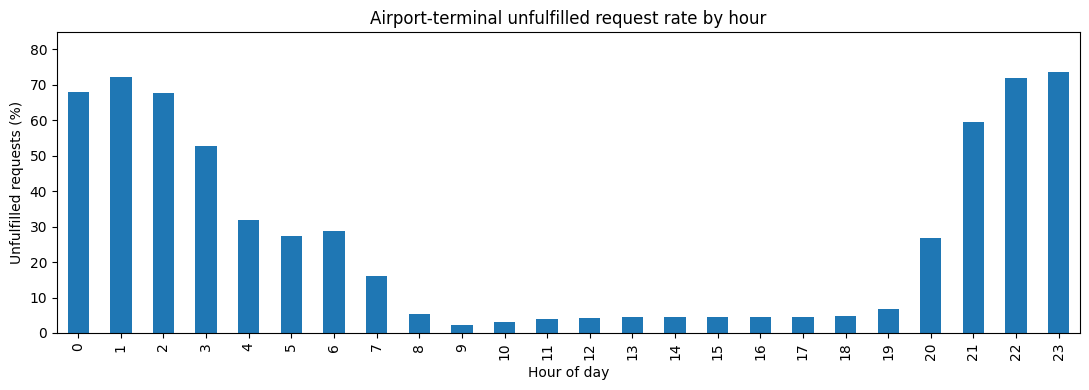

In [18]:
# Present the hourly pattern in chronological order for easier interpretation.
hourly_plot = hourly_pressure.sort_index()

ax = hourly_plot["unfulfilled_rate_pct"].plot(
    kind="bar",
    figsize=(11, 4)
)
ax.set_title("Airport-terminal unfulfilled request rate by hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Unfulfilled requests (%)")
ax.set_ylim(0, max(hourly_plot["unfulfilled_rate_pct"]) * 1.15)
plt.tight_layout()
plt.show()

### B1 takeaway

The mismatch is not evenly distributed across the day. Terminal unfulfilled demand is heavily concentrated in the **late-evening and overnight window, especially 21:00–03:00**, when unfulfilled rates are substantially higher and ETA/surge also rise.

This points toward a **time-targeted supply intervention** rather than indiscriminate acquisition throughout the day.

## 2. B2 - Post-airport-trip captain behavior

`airport_trips.csv` contains airport-origin trips. There is therefore **no non-airport trip group in this dataset** for a direct comparison.

Instead, I segment airport trips by `drop_zone_type` and compare:

- captain cancellation rate
- probability of a return fare within 20 minutes
- trip distance
- trip fare

These are descriptive associations, not causal estimates.

In [19]:
print("Unique pickup zones:", sorted(airport_trips["pickup_zone_id"].dropna().unique()))
print(
    "All trips have an airport pickup:",
    airport_trips["pickup_zone_id"].astype(str).str.startswith("APT-").all()
)

print("\nDrop-zone types:", sorted(airport_trips["drop_zone_type"].dropna().unique()))

Unique pickup zones: ['APT-T1', 'APT-T2']
All trips have an airport pickup: True

Drop-zone types: ['city_core', 'suburban', 'tech_park']


In [20]:
trip_summary = (
    airport_trips
    .groupby("drop_zone_type")
    .agg(
        trips=("trip_id", "count"),
        cancellation_rate=("captain_cancelled", "mean"),
        return_fare_rate=("got_return_fare_within_20min", "mean"),
        avg_distance_km=("trip_distance_km", "mean"),
        avg_fare_inr=("fare_inr", "mean")
    )
)

trip_summary["cancellation_rate_pct"] = trip_summary["cancellation_rate"] * 100
trip_summary["return_fare_rate_pct"] = trip_summary["return_fare_rate"] * 100

In [21]:
display(
    trip_summary[
        [
            "trips",
            "cancellation_rate_pct",
            "return_fare_rate_pct",
            "avg_distance_km",
            "avg_fare_inr"
        ]
    ].round(2)
)

,trips,cancellation_rate_pct,return_fare_rate_pct,avg_distance_km,avg_fare_inr
drop_zone_type,,,,,
city_core,25282,8.63,52.72,13.24,216.62
suburban,24643,21.00,16.53,23.38,353.57
tech_park,10075,8.96,41.43,16.10,255.23


In [22]:
overall_trip_metrics = pd.Series({
    "trips": len(airport_trips),
    "cancellation_rate_pct": airport_trips["captain_cancelled"].mean() * 100,
    "return_fare_rate_pct": (
        airport_trips["got_return_fare_within_20min"].mean() * 100
    )
})

In [23]:
print("\nOverall airport-trip metrics:")
display(overall_trip_metrics.to_frame("value").round(2))


Overall airport-trip metrics:


,value
trips,60000.00
cancellation_rate_pct,13.77
return_fare_rate_pct,35.96


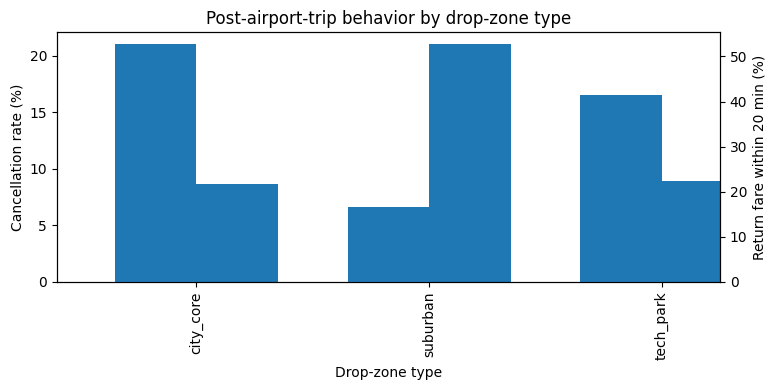

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))

trip_summary["cancellation_rate_pct"].plot(
    kind="bar",
    ax=ax,
    position=0,
    width=0.35,
    label="Captain cancellation %"
)

ax2 = ax.twinx()
trip_summary["return_fare_rate_pct"].plot(
    kind="bar",
    ax=ax2,
    position=1,
    width=0.35,
    label="Return fare within 20 min %"
)

ax.set_title("Post-airport-trip behavior by drop-zone type")
ax.set_xlabel("Drop-zone type")
ax.set_ylabel("Cancellation rate (%)")
ax2.set_ylabel("Return fare within 20 min (%)")
plt.tight_layout()
plt.show()

### B2 takeaway

Post-trip economics differ materially by destination.

**Suburban drops** stand out with the highest captain cancellation rate (**21.00%**) and the lowest return-fare availability within 20 minutes (**16.53%**). City-core and tech-park drops have substantially better return-fare availability.

This suggests that the airport supply problem is not only about the number of captains available. **Where captains end up, and whether they can quickly find another fare, may also matter for participation and utilization.**

The dataset does not establish that low return-fare availability causes cancellation, so this should be treated as a hypothesis to test.

## 3. Intervention decision

### Recommendation

Do **not** start with broad airport-catchment captain acquisition.

Instead, prioritize a **targeted airport supply intervention during 21:00–03:00**, with emphasis on captain economics and repositioning/return-fare availability.

A controlled pilot should measure:

- incremental fulfilled requests
- incremental captain participation / captain-hours
- captain cancellation
- cost per incremental fulfilled request
- whether supply is genuinely incremental or simply shifted from other zones

### Why this is the better first test

The airport mismatch is strongly time-concentrated, while post-trip behavior shows a clear destination-related difference in captain outcomes. A broad acquisition program could add supply at the wrong times or in the wrong locations and may not address the underlying utilization problem.

**Key limitation:** `airport_trips.csv` contains only airport-origin trips, so these cancellation and return-fare rates cannot be compared directly with non-airport trips.

## 4. Ranked recommendations

### 1. Fix RC verification friction

From the onboarding funnel, DL→RC is the largest captain-level leak. Prioritize better document-capture guidance, image-quality checks before submission, and clearer retake prompts.

**Illustrative scenario:** recovering 10% of RC drop-offs recovers roughly 549 captains. Applying the observed downstream approval conversion gives roughly 150 additional approvals. This is a scenario, not a causal forecast.

**Success metric:** RC clearance rate and signup→approved conversion.  
**Risk:** image-quality improvements will not address every verification failure.

### 2. Improve Fitness→Insurance completion

The Fitness→Insurance stage loses 3,340 captains and varies across acquisition and device segments. Prioritize targeted nudges or assisted completion for the weakest segments.

**Illustrative scenario:** recovering 10% of these drop-offs recovers roughly 334 captains. At the observed Insurance→Approval conversion, this corresponds to roughly 303 additional approvals.

**Success metric:** Fitness→Insurance conversion.  
**Risk:** assisted support may add operational cost.

### 3. Target airport supply during 21:00–03:00

The terminal problem is concentrated overnight, and post-airport-trip behavior indicates weaker outcomes for some destinations, particularly suburban drops.

Prioritize a targeted supply/repositioning incentive pilot rather than broad airport-catchment acquisition.

**Success metrics:** unfulfilled rate, fulfilled requests, incremental captain-hours, cancellation rate, and intervention cost.  
**Risk:** incentives may shift existing supply from other zones rather than create net-new supply.